# Wrapper Architecture

In [95]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


# Using Wrapper

## Data

In [84]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

# Data
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)
X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_val, X_cal, y_train_val, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print(f"Training set size: {len(y_train)}\n"
      f"Val set size: {len(y_val)}\n"
      f"Calibration set size: {len(y_val)}\n"
      f"Test set size: {len(y_test)}")

Training set size: 2560
Val set size: 640
Calibration set size: 640
Test set size: 1000


## Model

### Architecture

In [85]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

## Creating Wrapped Model
and fitting it

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':1
}

model = MLPClassifier(**model_parameter)
clf = MyWrapper(model=model, classes=np.array([0,1], dtype=np.int64), epochs=20, batch_size=256)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)
scores = cross_val_score(clf, X_val, y_val, cv=5)
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_val, y_pred))
print(scores)

Avrage Loss 0.33742993146181105
Avrage Loss 0.2643288463354111
Avrage Loss 0.2709461573511362
Avrage Loss 0.279876272380352
Avrage Loss 0.28400760926306245
Avrage Loss 0.27602150216698645
[[250  42]
 [ 63 285]]
0.8359375
[0.7890625 0.8671875 0.859375  0.8515625 0.875    ]


# Calibration

Avrage Loss 0.22010246875385442
Avrage Loss 0.22094471181432404
Avrage Loss 0.23054885442058248
Avrage Loss 0.21720147579908372
Avrage Loss 0.2300688130160172


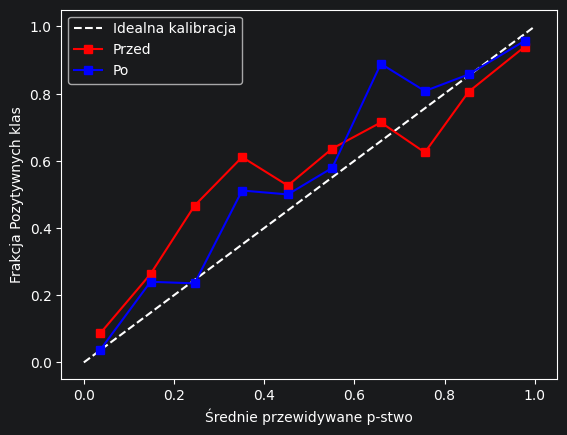

In [100]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

#calibrated_clf = CalibratedClassifierCV(clf, method='sigmoid')
calibrated_clf = CalibratedClassifierCV(clf, method='isotonic')
# calibrated_clf = CalibratedClassifierCV(clf,method='temperature')
calibrated_clf.fit(X_cal, y_cal)

# skalowanie metodą ‘ temperature’ jest dostepne od wersji scikit-learn 1.8.0
init_probs = clf.predict_proba(X_val)
calibrated_probs = calibrated_clf.predict_proba(X_val)
y_true = y_val

# --- Compute calibration curves ---
frac_pos_before, mean_pred_before = calibration_curve(
 y_true, init_probs[:,1], n_bins=10
)
frac_pos_after, mean_pred_after = calibration_curve(
 y_true, calibrated_probs[:,1], n_bins=10
)

plt.plot([0, 1], [0, 1], "w--", label="Idealna kalibracja")
plt.plot(mean_pred_before, frac_pos_before, "s-", color="red", label="Przed")
plt.plot(mean_pred_before, frac_pos_after, "s-", color="blue", label="Po")
plt.legend()
plt.xlabel("Średnie przewidywane p-stwo")
plt.ylabel("Frakcja Pozytywnych klas")
plt.show()